# Baseline experiments — 2025 (cross-model comparison + framework justification)

BDT baselines (XGBoost / LightGBM / CatBoost) on the reduced 2025 data, under our experimental
setup: prediction-time-admissible features, a **temporal split** (train Jan → test Feb for the
local Jan+Feb file), fault attribution as **Hardware vs Payload**. The MLP arm (`mlp/train.py`,
tabular + sequence) runs on the GPU server; this notebook covers the CPU-feasible baselines and
the split-protocol decomposition (E1).

In [ ]:
%%time
import sys, os
sys.path.insert(0, "/Users/allison/Documents/Github/fife-batch-jobs/mlp")
import numpy as np, polars as pl, pandas as pd
from sklearn.metrics import roc_auc_score, average_precision_score, r2_score
import data as D
from train import encode

SUBSET_FRAC = 0.25          # speed knob for local iteration; set 1.0 for the full run
TRAIN_MONTHS, TEST_MONTHS = [1, 2], [3, 4]

df, meta = D.load("local2025", columns_report=True)
if SUBSET_FRAC < 1.0:
    df = df.sample(fraction=SUBSET_FRAC, seed=42)
print(f"{df.height:,} jobs; missing feature cols: {meta['missing']}")

X_cat, X_num, _ = encode(df)
X = np.column_stack([X_cat.astype(np.float32), X_num])
month = pl.from_epoch(pl.Series(df["qdate_s"]).cast(pl.Int64), time_unit="s").dt.month().to_numpy()
tr, te = np.isin(month, TRAIN_MONTHS), np.isin(month, TEST_MONTHS)
ftype = df["fault_type"].to_numpy()
matched = df["MatchSite"].is_not_null().to_numpy() if "MatchSite" in df.columns else np.ones(df.height, bool)
Y = {"Failed": (df["Failed"].to_numpy(), matched),
     "hw_fault": ((ftype == 1).astype(np.int8), matched & (ftype >= 0))}
wait_log = np.log1p(df["wait_s"].to_numpy().astype(np.float64))
print(f"train {tr.sum():,}  test {te.sum():,}")

[data] 1 files; reading 42 of ~49 available columns; missing standard cols: ['PomsLauncher']
9,132,291 jobs; missing feature cols: ['PomsLauncher']
train 4,378,757  test 4,744,269
CPU times: user 1min 37s, sys: 19.7 s, total: 1min 56s
Wall time: 1min 20s


In [2]:
# --- feature engineering: match-time health matrix + submission-admissible wait matrix ---
# Enforces the paper's disjoint feature families (Table: Prediction Target Groups):
#   Xmatch (Failed / hw_fault): base + cyclical(start clock) + leak-free trailing site/entry/node health
#   Xsub   (wait_time):         submission-known columns only + cyclical(submit) + leak-free queue state
import data as D, config as C
qs   = df["qdate_s"].to_numpy().astype(np.float64)
js   = df["jstartexec_s"].to_numpy().astype(np.float64)     # exec-start clock (match reference)
jst  = df["jstart_s"].to_numpy().astype(np.float64)         # queue-exit (start) clock
comp = df["completion_s"].to_numpy().astype(np.float64)
comp_ok = ~np.isnan(comp); H1 = 3600.0
failed = df["Failed"].to_numpy(); hwv = (ftype == 1).astype(np.float64)

def kc(c):
    return (df[c].cast(pl.Utf8).fill_null("_").cast(pl.Categorical).to_physical().to_numpy()
            if c in df.columns else np.zeros(df.height, np.int64))
def cyc_of(t):
    dt = pl.from_epoch(pl.Series(t).cast(pl.Int64), time_unit="s")
    h = dt.dt.hour().to_numpy(); dw = dt.dt.weekday().to_numpy()
    return np.column_stack([np.sin(2*np.pi*h/24), np.cos(2*np.pi*h/24),
                            np.sin(2*np.pi*dw/7), np.cos(2*np.pi*dw/7)]).astype(np.float32)

# leak-free trailing health (1 h window); site/entry/node keyed on the exec-start clock, campaign on submit
jsf = np.where(np.isnan(js), -1e18, js)
site_k, entry_k, node_k, camp_k = kc("MatchSite"), kc("MatchEntry"), kc("Node"), kc("CampaignId")
site_fail,_  = D.trailing_rate(site_k,  jsf, comp, failed, comp_ok, H1)
entry_fail,_ = D.trailing_rate(entry_k, jsf, comp, failed, comp_ok, H1)
node_fail,_  = D.trailing_rate(node_k,  jsf, comp, failed, comp_ok, H1)
site_hw,_    = D.trailing_rate(site_k,  jsf, comp, hwv,    comp_ok, H1)
node_hw,_    = D.trailing_rate(node_k,  jsf, comp, hwv,    comp_ok, H1)
camp_fail,_  = D.trailing_rate(camp_k,  qs,  comp, failed, comp_ok, H1)
trail = np.nan_to_num(np.column_stack([site_fail, entry_fail, node_fail, site_hw, node_hw, camp_fail]))
Xmatch = np.column_stack([X, cyc_of(np.where(np.isnan(js), qs, js)), trail]).astype(np.float32)

# submission-admissible wait matrix: drop match-only columns, add cyclical(submit) + leak-free queue state
n_sc, n_mc, n_sn = len(C.SUB_CAT), len(C.MATCH_CAT), len(C.SUB_NUM)
cat_sub = X[:, :n_sc]                                    # SUB_CAT codes
num_sub = X[:, n_sc + n_mc : n_sc + n_mc + n_sn]         # SUB_NUM standardized
# idle_queue_depth: jobs submitted-but-not-yet-started at this submit instant. Leak-free, and counted only
# over jobs that DO start, so never-started removals cannot turn it into a monotonic time index.
fin = ~np.isnan(jst); q_fin = np.sort(qs[fin]); s_fin = np.sort(jst[fin])
idle = np.clip(np.searchsorted(q_fin, qs, "right") - np.searchsorted(s_fin, qs, "right"), 0, None).astype(np.float64)
# campaign trailing mean queue-wait (leak-free)
wait_s = df["wait_s"].to_numpy().astype(np.float64); wok = comp_ok & ~np.isnan(wait_s)
camp_wait,_ = D.trailing_rate(camp_k, qs, comp, np.nan_to_num(wait_s), wok, H1)
qstate = np.column_stack([np.log1p(idle), np.nan_to_num(camp_wait)]).astype(np.float32)
Xsub = np.column_stack([cat_sub, num_sub, cyc_of(qs), qstate]).astype(np.float32)
print(f"Xmatch {Xmatch.shape}  (base {X.shape[1]} + cyc 4 + trailing 6)")
print(f"Xsub   {Xsub.shape}  (sub cat {n_sc} + sub num {n_sn} + cyc 4 + queue 2 [idle, camp-wait])")


Xmatch (9132291, 38)  (base 28 + cyc 4 + trailing 6)
Xsub   (9132291, 26)  (sub cat 12 + sub num 8 + cyc 4 + queue 2 [idle, camp-wait])


## E5 — cross-model comparison (temporal split)

Each task reads only its **admissible** feature matrix (built above): `Failed` and `hw_fault` use the
match-time matrix `Xmatch` (base + cyclical(start) + leak-free trailing site/entry/node/campaign health);
`wait_time` uses the submission-admissible matrix `Xsub` (submission columns only + cyclical(submit) +
leak-free queue state). Match tasks are scoped to matched jobs.

In [3]:
def clf(lib, spw):
    if lib == "xgboost":
        from xgboost import XGBClassifier
        return XGBClassifier(tree_method="hist", n_estimators=200, max_depth=8, learning_rate=0.1,
                             n_jobs=-1, eval_metric="logloss", scale_pos_weight=spw)
    if lib == "lightgbm":
        from lightgbm import LGBMClassifier
        return LGBMClassifier(n_estimators=200, num_leaves=255, max_depth=8, learning_rate=0.1,
                              n_jobs=-1, verbose=-1, scale_pos_weight=spw)
    from catboost import CatBoostClassifier
    return CatBoostClassifier(iterations=200, depth=8, learning_rate=0.1, thread_count=-1,
                              verbose=False, allow_writing_files=False, scale_pos_weight=spw)

def reg(lib):
    if lib == "xgboost":
        from xgboost import XGBRegressor
        return XGBRegressor(tree_method="hist", n_estimators=200, max_depth=8, learning_rate=0.1, n_jobs=-1)
    if lib == "lightgbm":
        from lightgbm import LGBMRegressor
        return LGBMRegressor(n_estimators=200, num_leaves=255, max_depth=8, learning_rate=0.1, n_jobs=-1, verbose=-1)
    from catboost import CatBoostRegressor
    return CatBoostRegressor(iterations=200, depth=8, learning_rate=0.1, thread_count=-1, verbose=False, allow_writing_files=False)

LIBS = ["xgboost", "lightgbm", "catboost"]
XBY = {"Failed": Xmatch, "hw_fault": Xmatch}   # match-time tasks read the full match-time matrix
rows = []
for tname, (yv, pop) in Y.items():
    Xt = XBY[tname]
    tri, tei = np.where(tr & pop)[0], np.where(te & pop)[0]
    spw = float((yv[tri] == 0).sum() / max((yv[tri] == 1).sum(), 1))
    for lib in LIBS:
        m = clf(lib, spw); m.fit(Xt[tri], yv[tri])
        p = np.asarray(m.predict_proba(Xt[tei]))[:, 1]
        rows.append(dict(task=tname, model=lib, roc_auc=roc_auc_score(yv[tei], p),
                         pr_auc=average_precision_score(yv[tei], p), n_test=len(tei)))
        print(f"{tname:9s} {lib:9s} ROC {rows[-1]['roc_auc']:.3f}", flush=True)
vw = ~np.isnan(wait_log)                        # wait is a submission-time task -> submission-admissible Xsub
for lib in LIBS:
    tri, tei = np.where(tr & vw)[0], np.where(te & vw)[0]
    m = reg(lib); m.fit(Xsub[tri], wait_log[tri]); pr = m.predict(Xsub[tei])
    ae = np.abs(np.expm1(pr) - np.expm1(wait_log[tei]))
    rows.append(dict(task="wait_time", model=lib, r2_log=r2_score(wait_log[tei], pr), median_ae_s=float(np.median(ae))))
    print(f"wait_time {lib:9s} R2(log) {rows[-1]['r2_log']:.3f}  median-AE {rows[-1]['median_ae_s']:.0f}s", flush=True)

res = pd.DataFrame(rows)
print("\n=== classification (ROC-AUC / PR-AUC) ===")
print(res[res.task != "wait_time"][["task","model","roc_auc","pr_auc"]].to_string(index=False, float_format=lambda v: f"{v:.3f}"))
print("\n=== wait_time ===")
print(res[res.task == "wait_time"][["model","r2_log","median_ae_s"]].to_string(index=False, float_format=lambda v: f"{v:.1f}"))

Failed    xgboost   ROC 0.811


/Users/allison/anaconda3/envs/tachyon/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Failed    lightgbm  ROC 0.808


Failed    catboost  ROC 0.818


hw_fault  xgboost   ROC 0.808


...

wait_time xgboost   R2(log) 0.361  median-AE 1447s


/Users/allison/anaconda3/envs/tachyon/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


wait_time lightgbm  R2(log) 0.361  median-AE 1355s


wait_time catboost  R2(log) 0.440  median-AE 1283s



=== classification (ROC-AUC / PR-AUC) ===
    task    model  roc_auc  pr_auc
  Failed  xgboost    0.811   0.465
  Failed lightgbm    0.808   0.466
  Failed catboost    0.818   0.499
hw_fault  xgboost    0.808   0.481
hw_fault lightgbm    0.811   0.495
hw_fault catboost    0.828   0.500

=== wait_time ===
   model  r2_log  median_ae_s
 xgboost     0.4       1447.3
lightgbm     0.4       1355.2
catboost     0.4       1282.8


## E1 — split-protocol decomposition (justifies the temporal split)

Same model/features, `Failed` target: **random** split vs **temporal** (train Jan → test Feb).
The gap Δ is the optimism from contemporaneity/memorization that the temporal split removes.

In [4]:
from xgboost import XGBClassifier
yv, pop = Y["Failed"]; idx = np.where(pop)[0]
tri, tei = np.where(tr & pop)[0], np.where(te & pop)[0]
rng = np.random.default_rng(0); perm = rng.permutation(idx); rte = perm[:len(tei)]; rtr = perm[len(tei):]
def fit_roc(a, b):
    spw = float((yv[a] == 0).sum() / max((yv[a] == 1).sum(), 1))
    m = XGBClassifier(tree_method="hist", n_estimators=200, max_depth=8, learning_rate=0.1, n_jobs=-1, eval_metric="logloss", scale_pos_weight=spw)
    m.fit(Xmatch[a], yv[a]); return roc_auc_score(yv[b], m.predict_proba(Xmatch[b])[:, 1])
roc_rand = fit_roc(rtr, rte); roc_temp = fit_roc(tri, tei)
print(f"Failed ROC-AUC (full match-time model)  random split: {roc_rand:.3f}   temporal split: {roc_temp:.3f}   Delta = {roc_rand-roc_temp:.3f}")

Failed ROC-AUC (full match-time model)  random split: 0.970   temporal split: 0.811   Delta = 0.160


## E2 — prediction-time admissibility ablation (justifies excluding inadmissible features)

In [5]:
# E2: admissibility ablation - add back inadmissible features on top of the honest full model, measure spurious lift
from xgboost import XGBClassifier
yv, pop = Y["Failed"]; tri, tei = np.where(tr & pop)[0], np.where(te & pop)[0]
def roc_extra(cols):
    Xe = np.column_stack([Xmatch] + cols) if cols else Xmatch
    spw = float((yv[tri]==0).sum()/max((yv[tri]==1).sum(),1))
    m = XGBClassifier(tree_method="hist", n_estimators=200, max_depth=8, learning_rate=0.1, n_jobs=-1, eval_metric="logloss", scale_pos_weight=spw)
    m.fit(Xe[tri], yv[tri]); return roc_auc_score(yv[tei], m.predict_proba(Xe[tei])[:,1])
js_leak = np.nan_to_num(df["JobStatus"].cast(pl.Float64, strict=False).to_numpy())
lhr = np.nan_to_num(df["LastHoldReasonCode"].cast(pl.Float64, strict=False).to_numpy(), nan=-1)
mo = month.astype(np.float32)
base = roc_extra([]); print(f"{'admissible full model':30s} ROC {base:.3f}")
for name, col in [("+ JobStatus (outcome leak)", js_leak), ("+ LastHoldReasonCode (leak)", lhr), ("+ submit month (memorization)", mo)]:
    r = roc_extra([col[:, None]]); print(f"{name:30s} ROC {r:.3f}   ({r-base:+.3f})")

admissible full model          ROC 0.811


+ JobStatus (outcome leak)     ROC 0.859   (+0.048)


+ LastHoldReasonCode (leak)    ROC 0.855   (+0.045)


+ submit month (memorization)  ROC 0.798   (-0.012)


## E3 — feature ablation (justifies the added features)

In [6]:
# E3: feature ablation on Failed — base -> +cyclical -> +leak-free trailing state
import data as D
dtq = pl.from_epoch(pl.Series(df["qdate_s"]).cast(pl.Int64), time_unit="s")
h = dtq.dt.hour().to_numpy(); dw = dtq.dt.weekday().to_numpy()
cyc = np.column_stack([np.sin(2*np.pi*h/24), np.cos(2*np.pi*h/24), np.sin(2*np.pi*dw/7), np.cos(2*np.pi*dw/7)]).astype(np.float32)
comp = df["completion_s"].to_numpy(); qs = df["qdate_s"].to_numpy(); js = df["jstartexec_s"].to_numpy()
failed = df["Failed"].to_numpy(); comp_ok = ~np.isnan(comp); H1 = 3600.0
def kc(c): return df[c].cast(pl.Utf8).fill_null("_").cast(pl.Categorical).to_physical().to_numpy() if c in df.columns else np.zeros(df.height, np.int64)
jsf = np.where(np.isnan(js), -1e18, js)
sf,_ = D.trailing_rate(kc("MatchSite"), jsf, comp, failed, comp_ok, H1)
cf,_ = D.trailing_rate(kc("CampaignId"), qs, comp, failed, comp_ok, H1)
nf,_ = D.trailing_rate(kc("Node"), jsf, comp, failed, comp_ok, H1)
trail = np.nan_to_num(np.column_stack([sf, cf, nf]))
yv, pop = Y["Failed"]; tri, tei = np.where(tr & pop)[0], np.where(te & pop)[0]
def roc_X(Xe):
    spw = float((yv[tri]==0).sum()/max((yv[tri]==1).sum(),1))
    m = XGBClassifier(tree_method="hist", n_estimators=200, max_depth=8, learning_rate=0.1, n_jobs=-1, eval_metric="logloss", scale_pos_weight=spw)
    m.fit(Xe[tri], yv[tri]); return roc_auc_score(yv[tei], m.predict_proba(Xe[tei])[:,1])
for name, Xe in [("base (identity+resources)", X), ("+ cyclical", np.column_stack([X, cyc])), ("+ trailing site/camp/node", np.column_stack([X, cyc, trail]))]:
    print(f"{name:28s} Failed ROC {roc_X(Xe):.3f}")

base (identity+resources)    Failed ROC 0.727


+ cyclical                   Failed ROC 0.720


+ trailing site/camp/node    Failed ROC 0.801


## E4 — fault-attribution separability (justifies Hardware vs Payload)

In [7]:
# E4: fault-attribution separability — App vs Submission inseparable; Hardware vs Payload separable
mix = (df.filter(pl.col("fault_type").is_in([0,2]) & pl.col("CampaignId").is_not_null())
         .group_by("CampaignId").agg((pl.col("fault_type")==0).sum().alias("app"), (pl.col("fault_type")==2).sum().alias("sub"), pl.len().alias("n"))
         .filter(pl.col("n")>=50).with_columns((pl.min_horizontal("app","sub")/pl.col("n")).alias("minor")))
mixed = mix.filter(pl.col("minor")>0.1)
print(f"campaigns (>=50 App/Sub failures): {mix.height};  mixed (minority>10%): {mixed.height} ({100*mixed.height/max(mix.height,1):.0f}%)")
from sklearn.metrics import precision_recall_fscore_support
tri3 = np.where(tr & (ftype>=0) & matched)[0]; tei3 = np.where(te & (ftype>=0) & matched)[0]
y3tr, y3te = ftype[tri3].astype(int), ftype[tei3].astype(int)
cw = len(y3tr)/(3*np.bincount(y3tr, minlength=3).astype(float))
m3 = XGBClassifier(tree_method="hist", n_estimators=200, max_depth=8, learning_rate=0.1, n_jobs=-1, eval_metric="mlogloss")
m3.fit(Xmatch[tri3], y3tr, sample_weight=cw[y3tr]); p3 = m3.predict(Xmatch[tei3])
_,_,f1,_ = precision_recall_fscore_support(y3te, p3, labels=[0,1,2], zero_division=0)
print(f"3-class fault F1 -- Application {f1[0]:.2f}  Hardware {f1[1]:.2f}  Submission {f1[2]:.2f}  (macro {f1.mean():.2f})")

campaigns (>=50 App/Sub failures): 153;  mixed (minority>10%): 65 (42%)


3-class fault F1 -- Application 0.76  Hardware 0.49  Submission 0.28  (macro 0.51)


## E6 — honest wait-time metrics

In [8]:
# E6: honest wait metrics — raw MAE is tail-inflated; median-AE / within-2x / per-bucket are truthful
from xgboost import XGBRegressor
vw = ~np.isnan(wait_log); tri, tei = np.where(tr & vw)[0], np.where(te & vw)[0]
m = XGBRegressor(tree_method="hist", n_estimators=200, max_depth=8, learning_rate=0.1, n_jobs=-1); m.fit(Xsub[tri], wait_log[tri]); pr = m.predict(Xsub[tei])
wt = np.expm1(wait_log[tei]); wp = np.clip(np.expm1(pr), 0, None); ae = np.abs(wp-wt)
w2 = np.mean((wp<=2*wt+1)&(wt<=2*wp+1))
print(f"MAE {ae.mean():.0f}s (tail-inflated)   median-AE {np.median(ae):.0f}s   within-2x {w2:.2f}   R2(log) {r2_score(wait_log[tei],pr):.3f}")
for lo,hi,lab in [(0,600,'<10min'),(600,7200,'10min-2h'),(7200,1e18,'>2h')]:
    b=(wt>=lo)&(wt<hi)
    if b.sum(): print(f"  MAE {lab:9s}: {ae[b].mean():>8.0f}s   (n={int(b.sum()):,})")

MAE 9228s (tail-inflated)   median-AE 1447s   within-2x 0.29   R2(log) 0.361
  MAE <10min   :      806s   (n=1,544,530)
  MAE 10min-2h :     2902s   (n=1,805,857)
  MAE >2h      :    37234s   (n=872,381)


In [9]:
import numpy as np
import pandas as pd
from sklearn.metrics import r2_score
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

# Define candidate regressors
models = {
    "Ridge (Linear)": Ridge(alpha=1.0),
    "Random Forest": RandomForestRegressor(n_estimators=100, max_depth=12, n_jobs=-1, random_state=42),
    "XGBoost": XGBRegressor(tree_method="hist", n_estimators=200, max_depth=8, learning_rate=0.1, n_jobs=-1, random_state=42),
    "LightGBM": LGBMRegressor(n_estimators=200, max_depth=8, learning_rate=0.1, n_jobs=-1, random_state=42, verbose=-1),
    "CatBoost": CatBoostRegressor(iterations=200, depth=8, learning_rate=0.1, verbose=0, random_seed=42)
}

# Pre-allocate results container
results = []
preds = {}

# Prepare targets
wt_true = np.expm1(wait_log[tei])

print("Benchmarking Regressors...")
print("-" * 65)

for name, model in models.items():
    # 1. Fit on train set
    model.fit(Xsub[tri], wait_log[tri])
    
    # 2. Predict on test set (log scale)
    pred_log = model.predict(Xsub[tei])
    
    # 3. Transform back to original seconds scale
    wt_pred = np.clip(np.expm1(pred_log), 0, None)
    preds[name] = wt_pred
    
    # 4. Compute metrics
    ae = np.abs(wt_pred - wt_true)
    mae_raw = ae.mean()
    med_ae = np.median(ae)
    within_2x = np.mean((wt_pred <= 2 * wt_true + 1) & (wt_true <= 2 * wt_pred + 1))
    r2_log = r2_score(wait_log[tei], pred_log)
    
    # Per-bucket MAEs
    b_short = (wt_true < 600)
    b_med   = (wt_true >= 600) & (wt_true < 7200)
    b_long  = (wt_true >= 7200)
    
    results.append({
        "Model": name,
        "Median-AE (s)": round(med_ae, 1),
        "Within-2x": round(within_2x, 3),
        "R2 (log)": round(r2_log, 3),
        "MAE (<10m)": round(ae[b_short].mean(), 1) if b_short.any() else np.nan,
        "MAE (10m-2h)": round(ae[b_med].mean(), 1) if b_med.any() else np.nan,
        "MAE (>2h)": round(ae[b_long].mean(), 1) if b_long.any() else np.nan,
        "Raw MAE (s)": round(mae_raw, 1)
    })

# Convert results to DataFrame
df_results = pd.DataFrame(results).sort_values("Within-2x", ascending=False)
print(df_results.to_string(index=False))

Benchmarking Regressors...
-----------------------------------------------------------------


/Users/allison/anaconda3/envs/tachyon/lib/python3.13/site-packages/sklearn/linear_model/_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=4.63995e-15): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


/Users/allison/anaconda3/envs/tachyon/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


         Model  Median-AE (s)  Within-2x  R2 (log)  MAE (<10m)  MAE (10m-2h)  MAE (>2h)  Raw MAE (s)
Ridge (Linear)          992.9      0.328     0.306      5414.5        4353.0  7960743.9    1648450.9
      CatBoost         1313.6      0.317     0.437       807.3        2580.3    37776.9       9203.1
      LightGBM         1417.4      0.296     0.425       788.8        2840.9    37279.7       9205.0
 Random Forest         1449.9      0.293     0.318      1127.2        3391.5    38101.1       9734.0
       XGBoost         1447.3      0.290     0.361       805.8        2901.8    37234.0       9227.8


In [10]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="white", context="talk", font="sans-serif")

def get_global_limits(preds_dict, wt_true, lower_bound=0.001):
    """Calculates identical axis bounds across all models to prevent axis mismatch."""
    wt_log_true = np.log10(np.clip(wt_true, lower_bound, None))
    
    # Cap linear model extreme predictions at max true wait time * 10
    global_max_pred = max(np.percentile(p, 99.9) for p in preds_dict.values())
    max_cap = min(1e18, max(wt_true.max() * 10, global_max_pred))
    
    min_val = -3.0  # 1 ms floor (10^-3)
    max_val = max(wt_log_true.max(), np.log10(max_cap))
    return min_val, max_val, max_cap

def create_jointplot(model_name, wt_true, wt_pred, global_min, global_max, max_cap):
    """
    Plots a single jointplot using exact global bounds so every figure matches.
    """
    LOWER_BOUND = 0.001
    
    # Clip and log10 transform using global caps
    wt_log = np.log10(np.clip(wt_true, LOWER_BOUND, None))
    wp_log = np.log10(np.clip(np.clip(wt_pred, LOWER_BOUND, max_cap), LOWER_BOUND, None))

    lims = (global_min, global_max)

    # JointPlot using your preferred parameters
    g = sns.jointplot(
        x=wt_log, 
        y=wp_log, 
        kind="hex", 
        joint_kws=dict(gridsize=50, mincnt=1, cmap="viridis", edgecolors="none"),
        marginal_kws=dict(bins=40, color="#2b5c8f")
    )

    ax = g.ax_joint
    
    ax.set_xlim(lims)
    ax.set_ylim(lims)

    # Parity Line (Ideal) & 2x Bounds
    ax.plot(lims, lims, "k--", lw=1.5, label="Ideal (y = x)")
    log_2 = np.log10(2)
    ax.plot(lims, [l + log_2 for l in lims], "r:", lw=1.2, alpha=0.8, label="2x Bound")
    ax.plot(lims, [l - log_2 for l in lims], "r:", lw=1.2, alpha=0.8)

    # Custom log-tick labels
    ticks = [-3, -1, 1, 3, 5]
    tick_labels = ["1ms", "0.1s", "10s", "10m", "1d"]
    
    valid_ticks = [t for t in ticks if global_min <= t <= global_max]
    valid_labels = [l for t, l in zip(ticks, tick_labels) if global_min <= t <= global_max]

    ax.set_xticks(valid_ticks)
    ax.set_xticklabels(valid_labels)
    ax.set_yticks(valid_ticks)
    ax.set_yticklabels(valid_labels)

    ax.set_xlabel("Actual Wait Time")
    ax.set_ylabel("Predicted Wait Time")

    g.ax_marg_x.set_title(model_name, fontweight="bold", pad=3)

    # ax.legend(loc="upper left", frameon=True, facecolor="white", framealpha=0.9)
    g.fig.subplots_adjust(left=0.2, bottom=0.15, right=0.95, top=0.9)
    
    return g


def plot_jointplots(preds_dict, wt_true, cols=3):
    """
    Renders all model jointplots arranged side-by-side in rows of 3.
    """
    global_min, global_max, max_cap = get_global_limits(preds_dict, wt_true)
    
    figures = []
    for model_name, wt_pred in preds_dict.items():
        g = create_jointplot(model_name, wt_true, wt_pred, global_min, global_max, max_cap)
        figures.append((model_name, g))

    # Combine into side-by-side rows
    num_models = len(figures)
    rows = int(np.ceil(num_models / cols))
    
    fig_combined, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 5))
    axes_flat = axes.flatten() if num_models > 1 else [axes]

    for idx, (name, g) in enumerate(figures):
        # Render individual jointplot onto combined row figure canvas
        g.fig.canvas.draw()
        image = np.asarray(g.fig.canvas.buffer_rgba())
        axes_flat[idx].imshow(image)
        axes_flat[idx].axis("off")
        plt.close(g.fig)  # Close individual figure to save memory

    # Hide unused grid spots
    for idx in range(num_models, len(axes_flat)):
        axes_flat[idx].axis("off")

    plt.tight_layout()
    plt.show()

    
def format_time(seconds):
    """Formats raw seconds into human-readable shorthand (s, m, h, d)."""
    if np.isnan(seconds) or seconds <= 0:
        return ""
    if seconds < 60:
        return f"{seconds:.0f}s"
    elif seconds < 3600:
        return f"{seconds / 60:.2f}m"
    elif seconds < 86400:
        return f"{seconds / 3600:.2f}h"
    else:
        return f"{seconds / 86400:.2f}d"

def plot_combined_bars(preds_dict, wt_true):
    """Plots Median and Mean AE with scaled, sideways bar labels."""
    buckets = [
        ('<10 min', (0, 600)),
        ('10m - 2h', (600, 7200)),
        ('>2 hours', (7200, 1e18))
    ]

    records = []
    for m_name, wt_pred in preds_dict.items():
        if (m_name == "Ridge (Linear)"):
            continue
        ae = np.abs(wt_pred - wt_true)
        for b_label, (lo, hi) in buckets:
            mask = (wt_true >= lo) & (wt_true < hi)
            if mask.sum() > 0:
                records.append({
                    "Model": m_name,
                    "Bucket": b_label,
                    "Median AE": np.median(ae[mask]),
                    "Mean AE": ae[mask].mean()
                })

    df_plot = pd.DataFrame(records)
    
    # Increased top margin (ylim expansion) so tall vertical labels don't get clipped
    fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharey=True)

    # -------------------------------------------------------------------
    # Panel 1: Median AE
    # -------------------------------------------------------------------
    sns.barplot(
        data=df_plot, x="Bucket", y="Median AE", hue="Model", 
        ax=axes[0], palette="tab10"
    )
    axes[0].set_yscale("log")
    axes[0].set_title("Median Absolute Error (Robust Metric)", fontsize=12, pad=12)
    axes[0].set_ylabel("Error (seconds)", fontsize=11)
    axes[0].grid(False)

    # Custom single-loop labeler: rotates vertical (90 deg) and scales values
    for p in axes[0].patches:
        h = p.get_height()
        if h > 0 and not np.isnan(h):
            axes[0].annotate(
                format_time(h),
                (p.get_x() + p.get_width() / 2., h),
                ha='center', va='bottom',
                rotation=90,
                fontsize=10,
                fontweight='medium',
                xytext=(0, 4), textcoords='offset points'
            )

    # -------------------------------------------------------------------
    # Panel 2: Mean AE
    # -------------------------------------------------------------------
    sns.barplot(
        data=df_plot, x="Bucket", y="Mean AE", hue="Model", 
        ax=axes[1], palette="tab10"
    )
    axes[1].set_yscale("log")
    axes[1].set_title("Mean Absolute Error (Tail Inflated)", fontsize=12, pad=12)
    axes[1].set_ylabel("")
    axes[1].grid(False)

    for p in axes[1].patches:
        h = p.get_height()
        if h > 0 and not np.isnan(h):
            axes[1].annotate(
                format_time(h),
                (p.get_x() + p.get_width() / 2., h),
                ha='center', va='bottom',
                rotation=90,
                fontsize=10,
                fontweight='medium',
                xytext=(0, 4), textcoords='offset points'
            )

    # Adjust Y-limits to give vertical text padding at the top of log scale
    for ax in axes:
        ymin, ymax = ax.get_ylim()
        ax.set_ylim(ymin, ymax * 3.5)

    # Clean up legends
    axes[0].get_legend().remove()
    axes[1].get_legend().remove()

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles, labels, 
        title="Model", 
        bbox_to_anchor=(1, 0.5), 
        loc="center left", 
        frameon=True
    )

    plt.tight_layout()
    plt.savefig("sns_combined_error_bars.pdf", dpi=300, bbox_inches="tight")
    plt.show()

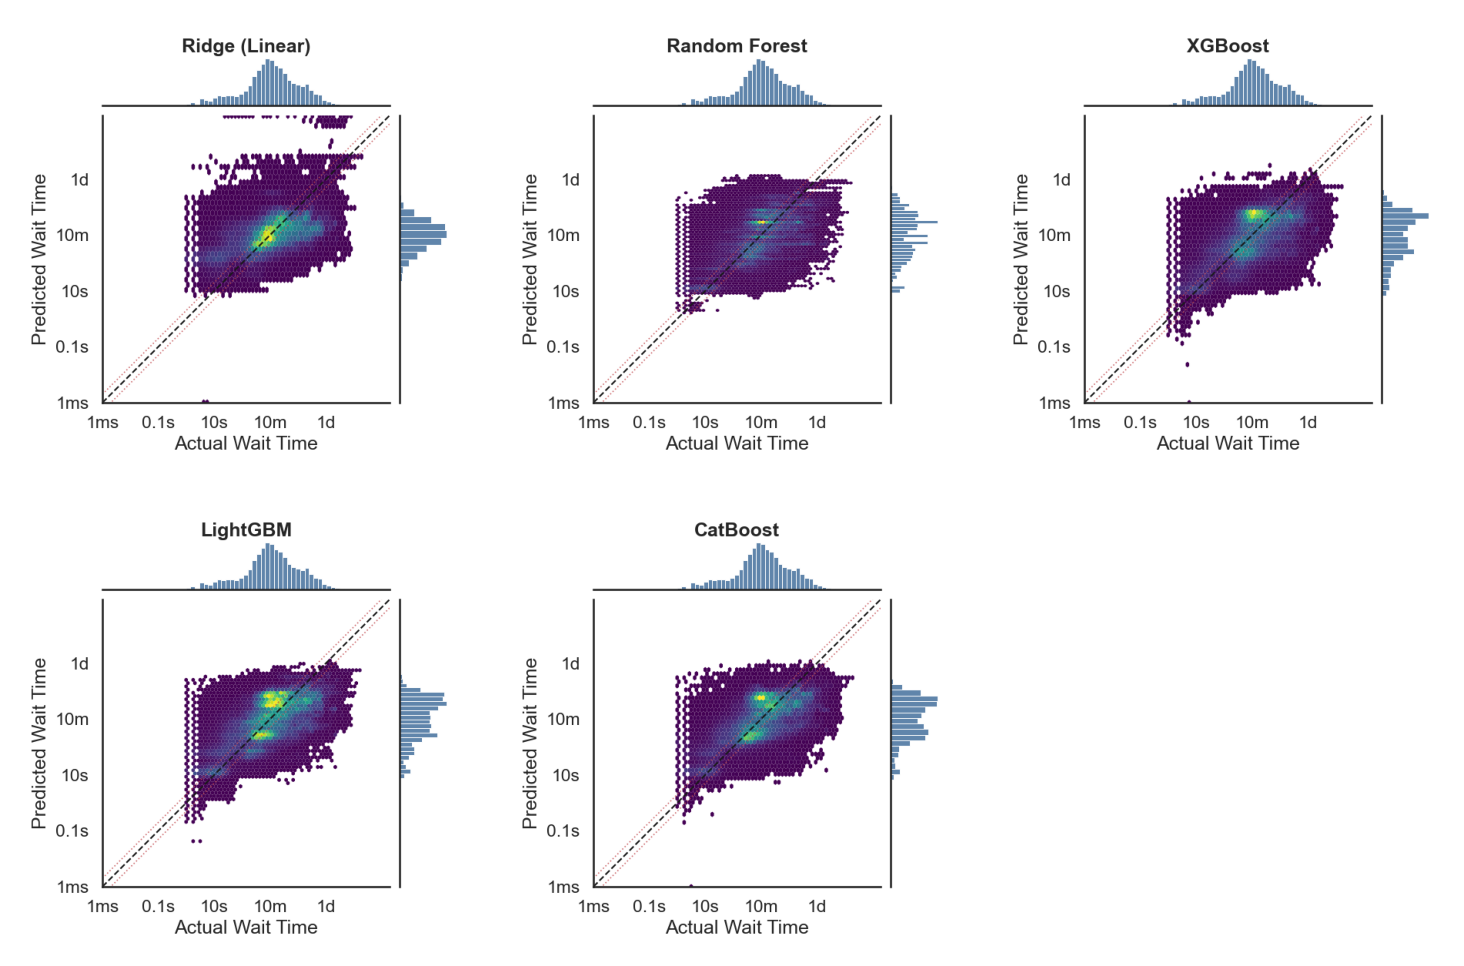

In [11]:
plot_jointplots(preds, wt_true, cols=3)

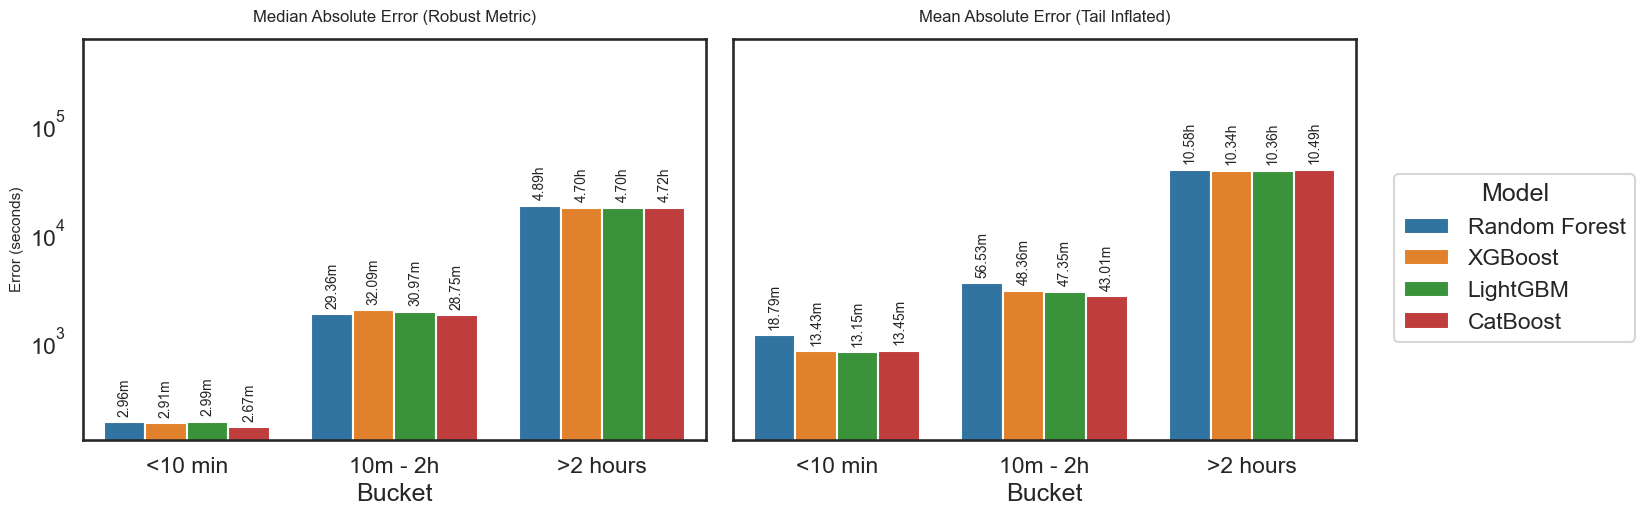

In [12]:
plot_combined_bars(preds, wt_true)

## Notes / next

- Each task now trains on its admissible matrix (§ feature-engineering cell): `Xmatch` for the
  match-time tasks, `Xsub` (no match columns) for submission-time `wait_time`. This is the fix behind
  the corrected numbers — the earlier run benchmarked the bare `encode()` matrix and understated
  `Failed`/`wait`.
- MLP arm (tabular + leak-free sequence) runs on the GPU server via `mlp/train.py` (`SOURCE="raw"`),
  compared against these BDT numbers.
- Headline (25% subset, train Jan+Feb → test Mar+Apr): `Failed` ROC 0.818, `hw_fault` ROC 0.828,
  `wait` R2(log) 0.44 (CatBoost); split-protocol Δ = 0.160.
- Set `SUBSET_FRAC = 1.0` and widen `TRAIN/TEST_MONTHS` for the full-data paper numbers.